# Lesson 113 · Scaling OGB: preserve the computation, measure the cost

Teacher solution · Three live tasks. Full arxiv bridge (CPU), optional full-products reproduction (GPU). **PENDING_WRITTEN_DEFENSE**.

In [1]:
# @colab-bootstrap: install in a fresh environment, then restart if required.
# Core notebook (CPU): torch, numpy, pandas, ogb, scikit-learn.
# Exact cloud versions and compiled sampling wheels: labs/requirements-l113-runtime.txt
# and the commands in labs/l113-reproduction.md. Full reproduction is OFF by default.
import sys, importlib.metadata
print('Python',sys.version)
print({k:importlib.metadata.version(k) for k in ['torch','numpy','pandas','ogb']})


Python 3.12.3 (main, Aug 31 2026, 10:18:26) [GCC 13.3.0]
{'torch': '2.13.0+cpu', 'numpy': '2.5.0', 'pandas': '3.0.3', 'ogb': '1.3.6'}


## 1 · The next bottleneck is computation

In [lesson 112](https://avistian.github.io/relational/lessons/0112-ogb-gcn-reproduction.html), you followed one full-graph GCN from citation edges to a validation-selected prediction. Every gradient step propagated through all 169,343 papers. That made the experiment easy to define: one graph, one objective, one optimizer step per epoch.

Now ask a practical question: **what must change when the intermediate node representations are too large to train together?** This lesson's tangible win is to construct an induced mini-batch, trace exactly which messages it removes, and defend a compute-and-accuracy report. The larger experiment uses **ogbn-products**, with 2,449,029 nodes. These scaling skills prepare you for relational entity graphs in Year 4, where a row prediction can depend on millions of connected records.

> **In plain terms.** Mini-batching decides which part of a graph participates in one update. It can reduce the amount of work held in memory. It also changes what the model sees during that update.



**Cold retrieval.** Before reading onward: (1) Does masking the loss remove test nodes from propagation? (2) Why must a GCN checkpoint include batch-normalization buffers? (3) What is cut when a cluster is processed alone? Write one sentence per question. Revisit [L089](https://avistian.github.io/relational/lessons/0089-sampling-at-scale.html), [L108](https://avistian.github.io/relational/lessons/0108-temporal-neighbor-sampling.html), and L112 after attempting the questions.

<details><summary>Check the retrieval</summary><p>Loss masking restricts label supervision; it does not remove feature paths. Batch-normalization running means and variances affect evaluation, so weights alone are insufficient. A cluster processed alone loses edges to excluded nodes; combining clusters can restore edges between those selected clusters.</p></details>

The primary reading is [Hu et al., OGB §4.1 and Table 4](https://arxiv.org/html/2005.00687v6#S4.SS1). Pair it with [Chiang et al., Cluster-GCN](https://arxiv.org/abs/1905.07953) for the sampling mechanism. Read OGB's footnote about the aggregation architecture before interpreting the result.



## 2 · Separate the sampling rule from the model

**A model** maps features and a graph to predictions. **A sampler** constructs the graph or computation neighborhood used for a training update. They are separate choices. The name “ClusterGCN” in OGB Table 4 refers to a cluster-based training method; its released model uses **GraphSAGE neighbor aggregation**. Replacing L112's normalized GCN with that model changes more than the batch size.

We therefore maintain two explicit experiments:

| Experiment | Fixed elements | Changed elements | What it answers |
|---|---|---|---|
| L112 bridge | Full arxiv data, GCN architecture, initialization, two passes over training labels | Full graph versus four random induced batches; degrees, BN populations, number of updates | What changes when we mini-batch this GCN? |
| Named OGB reproduction | Official products data and split, released SAGE architecture and cluster schedule | Modern recorded runtime and a newly computed fixed METIS partition | Can we replay the selected published experiment within budget? |

The bridge is deliberately short and uses random partitions. It demonstrates the conversion and its confounds. It is not an accuracy comparison between converged samplers. The named experiment is the place for a published score comparison.



**Prediction.** If both arms see every training label twice, do they take the same number of optimizer steps? Commit before opening the bridge results in section 7.



## 3 · Model architecture: follow one product

<figure tabindex="0" style="overflow-x:auto">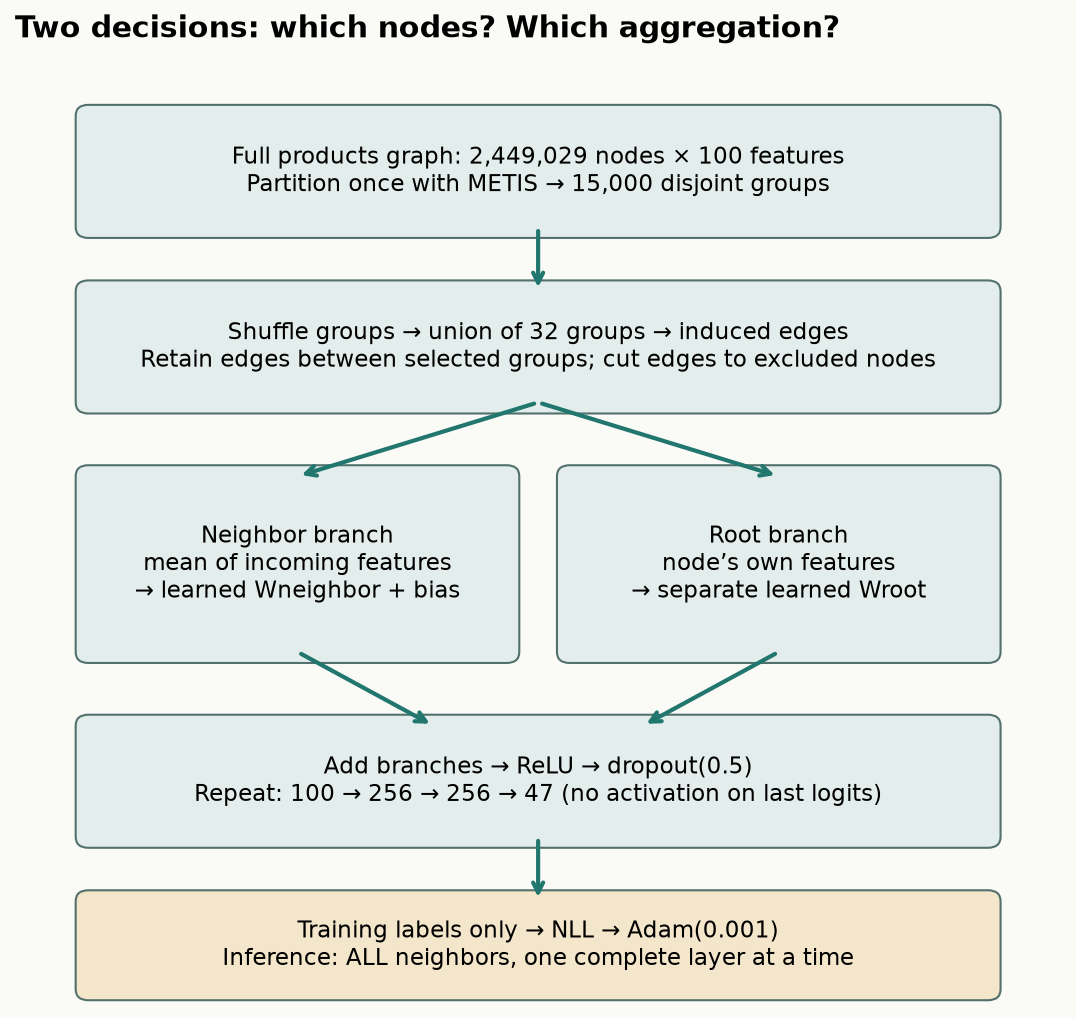<figcaption>Sampling selects an induced graph; GraphSAGE defines the messages. Follow both branches through training and complete-neighbor inference.</figcaption></figure>

**Inputs.** Each product has 100 numeric features. The graph is an undirected co-purchasing graph. The prediction is one of 47 product categories. The official split ranks products by popularity: 196,615 training nodes, 39,323 validation nodes, and 2,213,091 test nodes. We preserve the released IDs; a random split would answer a different generalization question. See the [OGB dataset specification](https://ogb.stanford.edu/docs/nodeprop/#ogbn-products).

**Visibility.** This is transductive training: the full feature graph is eligible for partitioning and messages, including validation and test nodes. Only training labels enter the objective. Validation labels select a checkpoint. Test labels evaluate the selected predictor. A label mask protects supervision; it does not make an experiment inductive or point-in-time valid. Connect this distinction to [L109's timestamp contract](https://avistian.github.io/relational/lessons/0109-database-timestamp-contracts.html).

**Partition once.** METIS is a provided graph-partitioning library. It groups nodes while trying to reduce edges crossing group boundaries. We form 15,000 disjoint groups and reuse that fixed partition across runs. The original partition was not released. The saved partition and its hash are part of our experiment identity.

**Form a batch.** Shuffle the groups and choose 32. Let B be the union of their nodes. The induced subgraph contains every original edge whose two endpoints both belong to B. It includes edges between selected groups. It excludes edges from B to unselected nodes. The average batch has approximately 2,449,029 × 32 / 15,000 ≈ 5,225 nodes, but actual sizes and edge counts vary.

**Aggregate.** For receiver i, let N_B(i) be its incoming neighbors inside that batch. Define mᵢ as their mean hidden feature vector; use the zero vector if there are no neighbors. A released SAGE layer computes:

**zᵢ = W_neighbor mᵢ + b + W_root hᵢ.**

Here hᵢ is the node's current feature vector. The two W matrices are learned linear maps. The bias b belongs to the neighbor branch; the root branch has no additional bias. Raw self-edges, if present, remain in the neighbor aggregation. We add no new self-loops. Duplicate raw edges retain multiplicity in the mean, matching the released edge-index operator.

This differs from L112's **S H Wᵀ + b**, where S contains symmetric degree normalization and one self-loop per node. SAGE uses separate root and neighbor weights. The products model has no batch normalization and no L2 normalization of the hidden vector.

**Stack layers.** The widths are **100 → 256 → 256 → 47**, for **206,895 trainable parameters**. The first two layers apply ReLU, then dropout with probability 0.5. ReLU clips negative values to zero; dropout randomly zeros activations during training. The last layer produces class logits. Log-softmax converts them to log-probabilities for negative log-likelihood, or NLL. The loss averages only over training nodes present in the batch. Adam uses learning rate 0.001. These choices follow the [pinned publication-era release](https://github.com/snap-stanford/ogb/blob/cf066f93311ab3099cad84d71085d1b0375dcc2e/examples/nodeproppred/products/cluster_gcn.py).

**Read the operator.** In this PyTorch class, `lin_l` is the neighbor transform and `lin_r` is the root transform. Sparse matrix multiplication computes the incoming means before the learned transform. `root` permits inference chunks to use just their own receiver rows while reading a complete previous-layer feature matrix.

See the visible implementation cell below for `MeanSAGE`.

**Task 1 · incoming means.** Implement `mean_adjacency`. A sparse adjacency stores nonzero entries instead of an N-by-N dense matrix. Its rows are receivers, columns are senders. Dividing each incoming entry by its receiver's degree produces a neighbor mean. The CHECK includes a directed graph and an isolated node so an accidental transpose or added self-loop fails.



## 4 · Work the boundary by hand

<figure tabindex="0" style="overflow-x:auto">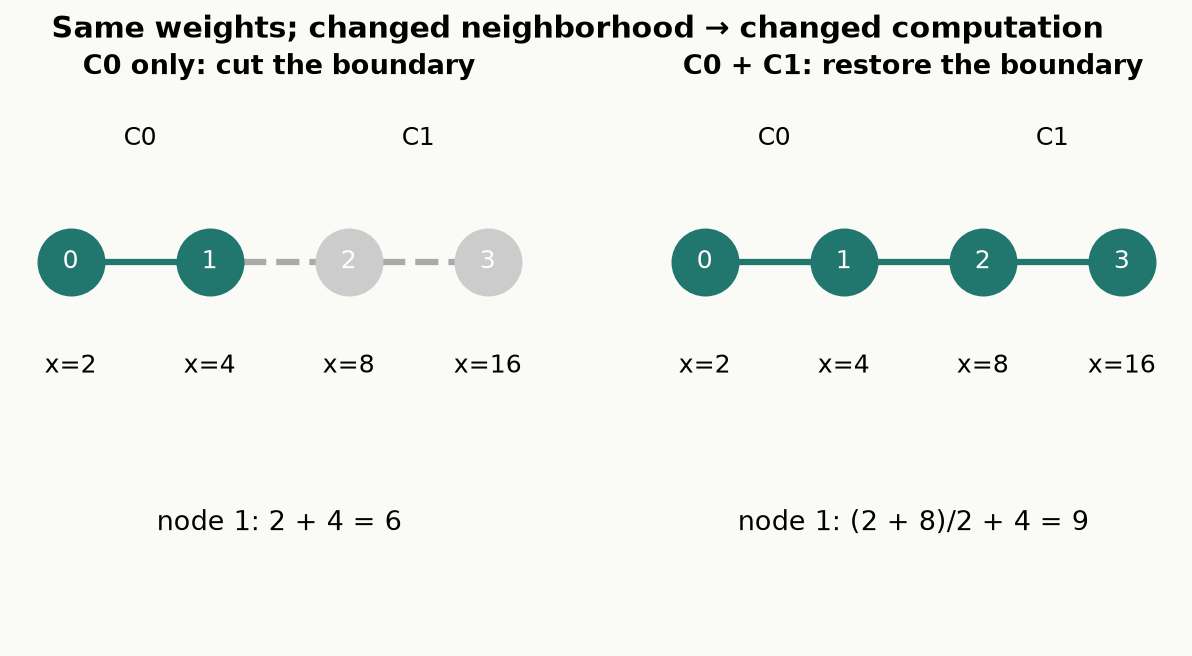<figcaption>Synthetic scalar trace, weights1 and bias0. Removing node2 changes both the incoming sum and the degree of receiver1.</figcaption></figure>

**Worked example.** Consider the path 0—1—2—3, with scalar features `[2, 4, 8, 16]`. Cluster C0 contains nodes 0 and 1; C1 contains nodes 2 and 3. Set both SAGE weights to 1 and the bias to 0.

On the full graph, node 1 sees neighbors 0 and 2. Its neighbor mean is (2 + 8) / 2 = 5. Its root feature is 4. Its output is **5 + 4 = 9**.

In a C0-only batch, node 2 is absent. The neighbor mean becomes 2, so node 1 outputs **2 + 4 = 6**. Both the missing message and the denominator changed. When C0 and C1 enter the same induced batch, edge 1—2 returns and the output becomes 9 again.

**Predict before moving the control:** will adding a third cluster that is farther down the path change this one-layer output? Why might it change a deeper model?

**Static control state:** C0 only → output6; C0+C1 → output9. Adding C2 keeps this one-layer output9.

<details><summary>Check the prediction</summary><p>A third cluster does not change node 1's immediate neighbors, so this one-layer output stays 9. At greater depth, features from farther nodes can travel along additional hops. A complete immediate neighborhood is not necessarily a complete multi-layer computation neighborhood.</p></details>

**Task 2 · preserve identities.** Implement `induced_edges`. If a batch stores global nodes `[2, 1]`, its local row 0 is global node 2, and local row 1 is global node 1. Keeping global edge IDs while slicing the features connects the wrong rows or indexes out of bounds. The CHECK deliberately reverses node order and also tests a batch with no retained edges.

**Loss weighting.** A batch averages NLL over its own training nodes, then takes an optimizer step. Batches can contain different numbers of labeled nodes. This is not one globally averaged gradient accumulated at fixed weights; parameters change between steps. Recall [L100](https://avistian.github.io/relational/lessons/0100-heterogeneous-gnn-checkpoint.html) when comparing these procedures.

**Why not just process each cluster separately?** Doing so would discard even the edges between clusters that were chosen together. Multi-cluster batching restores those edges. The [pinned PyG ClusterLoader implementation](https://pytorch-geometric.readthedocs.io/en/2.6.1/_modules/torch_geometric/loader/cluster.html) is provided infrastructure; the lab's small induced-subgraph oracle checks the semantic contract independently.

> **Scope check.** The mean of sampled neighbors can estimate a full neighbor mean under particular sampling assumptions. That does not make an entire nonlinear multi-layer loss or gradient unbiased. Cluster inclusion is also not uniform independent neighbor sampling. This lesson makes no unbiased-gradient claim.



## 5 · Budget the whole computation

A **hidden representation** is the feature vector produced by an intermediate layer. With N nodes, H channels, and float32 storage, one dense representation requires **N × H × 4 bytes**. A GiB is 2³⁰ bytes.

**Worked example.** For products at width 256, one hidden buffer is 2,449,029 × 256 × 4 = 2,507,805,696 bytes, or approximately **2.34 GiB**. Two saved hidden layers already approach 4.67 GiB before gradients, graph storage, optimizer state, input features, activations and temporary workspaces. This arithmetic is a lower-level sizing calculation, not a measured peak-memory prediction.

**Neighbor sampling.** Starting from B target nodes, three hops with fanouts f₁, f₂, f₃ can expand to at most B × (1 + f₁ + f₁f₂ + f₁f₂f₃) node occurrences before overlap is removed. A fanout is the maximum number of neighbors drawn per receiver at a hop. Real samplers can deduplicate shared neighbors. Low-degree nodes can contribute fewer neighbors.

<figure tabindex="0" style="overflow-x:auto">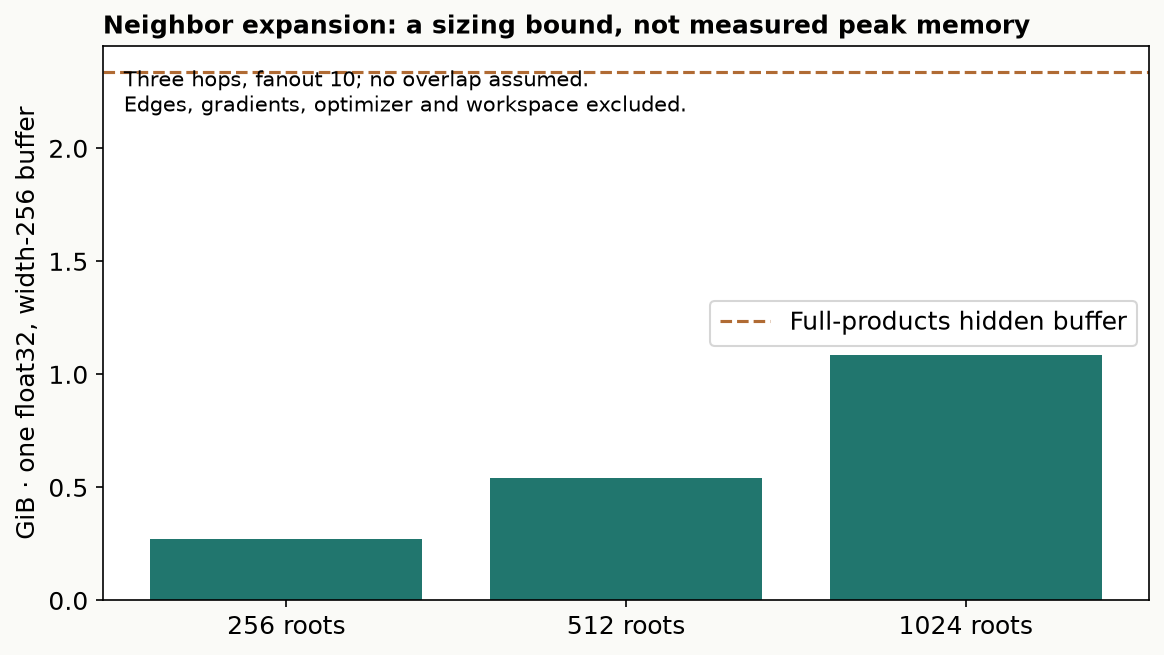<figcaption>Sizing calculation for one hidden feature buffer, not measured GPU peak. Three hops, fanout10, before deduplication.</figcaption></figure>

**Static sizing state:** 256 roots, fanout10, three hops → 284,416 occurrences and 0.271GiB for one width256 buffer.

**Cluster sampling.** Choose an induced batch first; all layers operate within its nodes. This avoids the same hop-by-hop growth, but cuts boundary context. Neither approach is universally faster: graph structure, implementation, fanouts, partition quality and CPU-to-GPU transfer matter. [GraphSAGE](https://arxiv.org/abs/1706.02216) explains sampled neighborhoods; [Cluster-GCN](https://arxiv.org/abs/1905.07953) motivates dense subgraph batches.

A credible compute note separates **download/preprocessing**, **partitioning**, **training**, and **evaluation**. Record peak allocated GPU memory with its measurement boundary. PyTorch's allocated-memory counter excludes some non-PyTorch allocations and CPU storage. Do not describe it as the whole machine's memory use.

**Budget rule.** This lesson has a $10 aggregate allowance. Data preparation, pilots, all seeds, retries and verification share it. We use a timed pilot and a reserve before launching complete runs. The [budget ledger](https://avistian.github.io/relational/labs/_budget_l113.json) records rates and caps. A credit balance does not raise the allowance. A faster partial run does not count as a completed published schedule.



## 6 · Small batches for training; complete neighborhoods for inference

<figure tabindex="0" style="overflow-x:auto">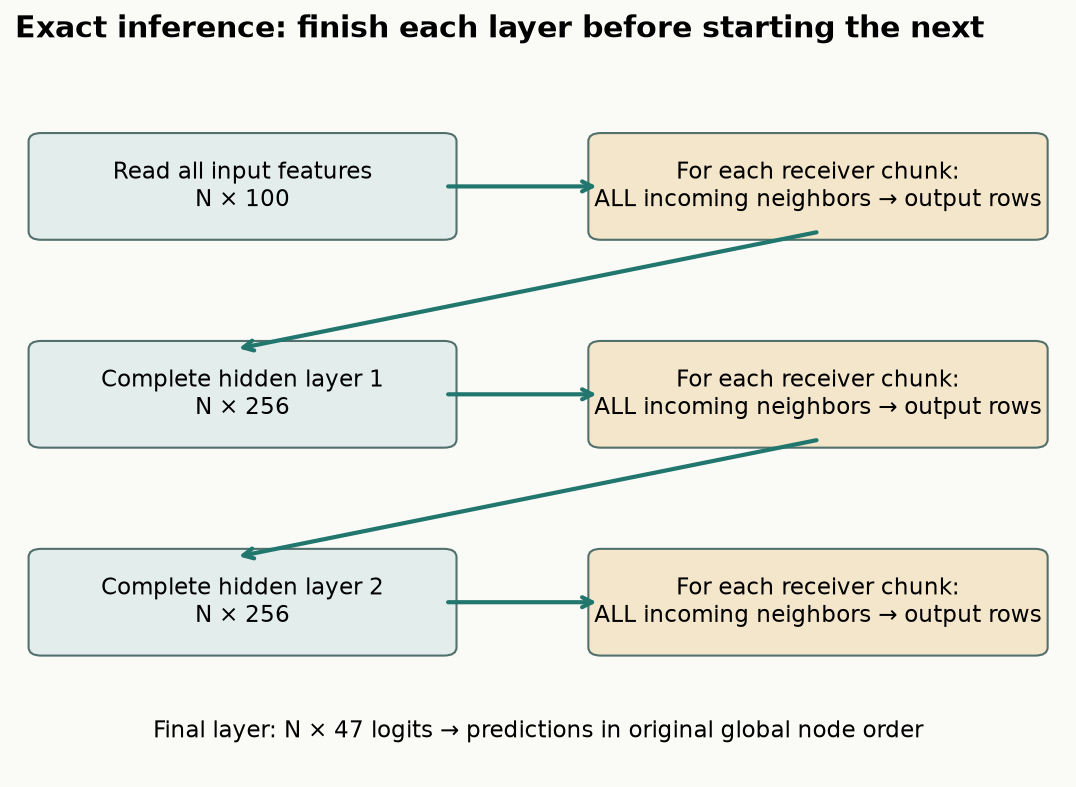<figcaption>Every current-layer row is written before the next layer reads it. All incoming neighbors participate, including neighbors outside the receiver chunk.</figcaption></figure>

Training on induced subgraphs does not require evaluating on those same cut graphs. At evaluation, we use the complete released graph. We can still limit memory by working **one layer at a time** and splitting the receivers into chunks.

For layer 1, keep the input feature matrix fixed. For each receiver chunk, fetch **all** of its incoming neighbors and compute that chunk's outputs. Write them to their global rows. Only after every node's layer-1 output exists may layer 2 begin. Repeat for all three layers. Disable dropout. Finally choose the largest logit per node.

**Why is this exact?** Within a fixed layer, a receiver's output depends on previous-layer features, not on another receiver's newly computed current-layer output. Chunking receivers therefore changes the execution order without cutting neighbor context. Running all three layers on each isolated chunk would violate that condition and cut dependencies.

The visible implementation keeps the previous feature matrix on the device and streams sparse adjacency rows into receiver chunks. It retains output features on the CPU between layers. This still requires one complete previous-layer feature matrix to fit on the GPU. It is sufficient for this products experiment; a larger graph may require gathering neighbor features from CPU memory or storage. Small training batches alone do not establish end-to-end scalability. This is a modern execution strategy; it is not a claim of historical runtime identity. The CHECK compares three chunk sizes, including one receiver at a time, against a dense full-graph calculation.

**Read the inference loop.** `rowptr` marks the start and end of each receiver’s entries in CSR storage. Each sparse block has rows for the current receivers and columns for all previous-layer nodes. The `out` matrix is completed before replacing `x`.

See the visible implementation cell below for `layerwise_inference`.

**Select consistently.** The released schedule trains for 50 epochs and evaluates at epochs **20, 25, 30, 35, 40, 45, 50**. Select the **first** maximum validation accuracy among those candidates. Store that model and its predictions. Report its test score. Evaluating every epoch would create additional selection opportunities and change the protocol.

**Task 3 · checkpoint selection.** Implement `selected_epoch`. The CHECK gives the best test score to a worse-validation candidate and includes a validation tie. Your function must ignore test scores and preserve the first tie.



## 7 · Evidence: what actually ran?

### The GCN conversion

**Author-reference teaching run: full arxiv, two epochs, seed113.**

| Training | Steps | Largest batch | Sparse entries per label pass | Time incl. final evaluation | Test accuracy |
|---|---:|---:|---:|---:|---:|
| full | 2 | 169,343 | 2,484,941 | 14.93 s | 27.21% |
| mini | 8 | 42,336 | 749,277 | 9.48 s | 48.08% |

Preprocessing excluded from these times. One CPU thread; recorded workspace runtime. These are short teaching runs, not convergence results.

These arms share initialization, data, architecture, learning rate and two label passes. The mini-batch arm takes eight optimizer steps instead of two, uses smaller batch-normalization populations and changes normalized neighborhoods. Its different accuracy cannot be attributed to memory reduction alone. At two epochs neither arm is a converged baseline. The result teaches the implementation change and identifies variables a rigorous comparison would need to control or study separately.

### The named products experiment

**Named ten-run experiment: COMPLETE.** 10/10 completed full schedules.

| Seed | Selected epoch | Validation accuracy | Test accuracy | Training + evaluation seconds |
|---|---:|---:|---:|---:|
| 0 | 40 | 91.677% | 77.864% | 892.9 |
| 1 | 50 | 91.628% | 78.505% | 891.0 |
| 2 | 40 | 91.677% | 78.380% | 871.5 |
| 3 | 50 | 91.722% | 78.078% | 887.0 |
| 4 | 50 | 91.778% | 78.098% | 916.1 |
| 5 | 45 | 91.819% | 78.707% | 1020.5 |
| 6 | 45 | 91.494% | 78.468% | 1005.5 |
| 7 | 40 | 91.761% | 78.554% | 1004.4 |
| 8 | 40 | 91.661% | 78.668% | 1016.7 |
| 9 | 40 | 91.702% | 78.339% | 918.5 |

valid: 91.6919% ± 0.0908pp (sample seed SD), CLOSE; test: 78.3660% ± 0.2749pp (sample seed SD), OUTSIDE_TOLERANCE. Historical identity and whole-paper parity are not established.

[Machine-readable results](https://avistian.github.io/relational/labs/evidence/l113/summary.json).

**Measured full-data pilot:** 17.05s per training epoch; 12.81s for exact inference; 2.73GiB peak PyTorch GPU allocation across training and evaluation. Throughput: 11,533 supervised nodes/s during training. This two-epoch timing run is not a score reproduction.

<figure tabindex="0" style="overflow-x:auto">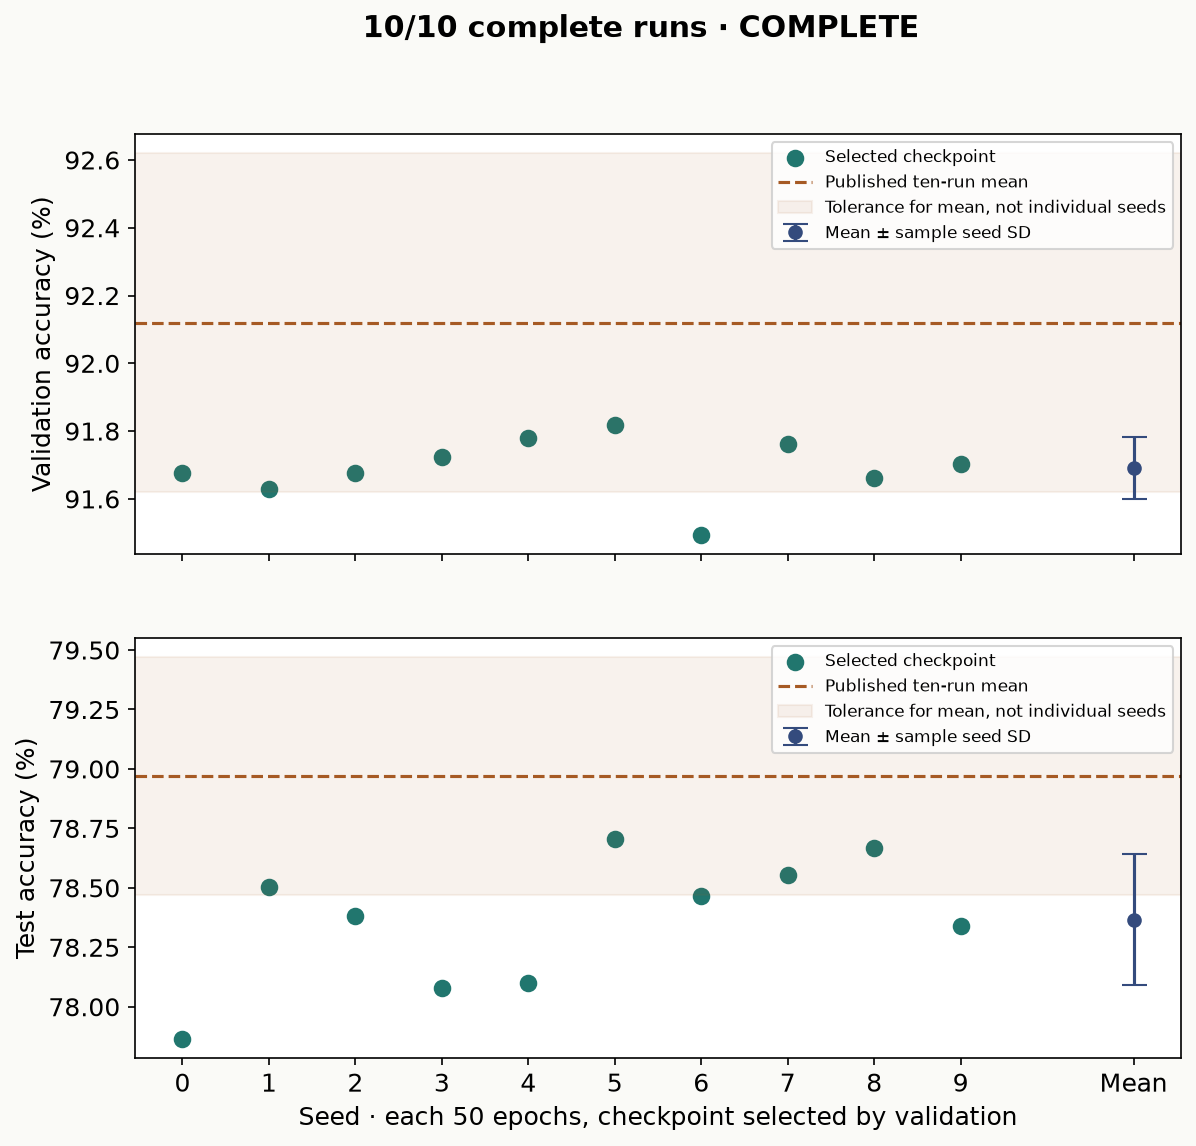<figcaption>Author evidence, separate from learner execution. Only full 50-epoch runs count toward the ten-run target.</figcaption></figure>

The published target is **validation 92.12 ± 0.09% and test 78.97 ± 0.33%**, reported over ten runs. Our predeclared numerical rule is a mean within **0.5 percentage point** of the corresponding published mean. This is a descriptive tolerance, not an equivalence test. We report sample seed standard deviation without forcing it to match. A seed spread measures variability on this fixed dataset and split, not uncertainty across all possible deployment datasets.

> **Scope check.** A source-parity check establishes a computation comparison under recorded conditions. A pilot establishes execution and timing. Only completed full-schedule runs support a selected-experiment score report. Even ten numerically close runs do not establish the original random seeds, historical METIS partition, bitwise identity or reproduction of the entire OGB paper.

**Interpret the numerical miss.** The completed test mean is 0.604 percentage points below the published mean, exceeding our 0.5-point tolerance. We therefore record `OUTSIDE_TOLERANCE`. Independent replay through the released model agrees on all 24,490,290 selected-checkpoint class predictions. That rules out a discrepancy in those replayed classes; it does not establish equality of the training trajectories. A new METIS partition, unspecified original random seeds and a modern sparse/runtime stack remain potential differences, but this experiment does not isolate their causal effects. We do not retune against the observed test result.

The [protocol ledger](https://avistian.github.io/relational/labs/l113-reproduction.md) separates these claims, including the released logging bug, modern runtime, partition provenance, initialization and inference execution differences. The primary source remains authoritative for its own result; local evidence is reported under its actual scope.



## 8 · Lab, defense and spaced return

Open the [student notebook](https://avistian.github.io/relational/labs/0113-scaling-ogb.ipynb), [prepared notebook](https://avistian.github.io/relational/labs/html/0113-scaling-ogb.html), or [teacher solution](https://avistian.github.io/relational/labs/solutions/0113-scaling-ogb.ipynb). The notebook contains the complete visible SAGE model and trainer, independent CHECKs, the GCN bridge, and a gated full-data reproduction path. See the [quick reference](https://avistian.github.io/relational/reference/scaling-ogb.html) and [exact commands](https://avistian.github.io/relational/labs/l113-reproduction.md).

**EXIT.** Submit your three functions, your bridge output, and a short compute note. Defend these four points:

1. Trace node 1's output before and after cutting its boundary edge. Explain the denominator as well as the missing message.
2. Explain why converting L112 to mini-batches changes more than GPU memory. Name the changes to degrees, batch normalization and update count.
3. Explain why receiver-chunked, layerwise inference preserves complete-graph computation, while independent subgraph inference does not.
4. State exactly which evidence supports the products result. If the run is partial, explain why you cannot report a ten-seed reproduction verdict.



**Teach back.** In 120 words, explain why the word “GCN” in ClusterGCN does not identify the products aggregation operator. Then connect that distinction to a future relational model: which choices determine the row encoder, which determine message passing, and which determine the sampled computation graph?

**Return tomorrow.** Reconstruct the 2.34 GiB calculation without notes. In one week, draw the two-stage inference dependency and identify where a premature layer transition breaks it. Ask the teaching agent for feedback on any unclear step and for grading of your written defense. Author execution does not establish learner mastery: **PENDING_WRITTEN_DEFENSE**.


## Visible implementation · OGB products

The following code is the canonical model and trainer. METIS and PyG ClusterLoader supply partitioning infrastructure; the graph algebra, loss and training logic remain visible. [MIT source license](https://github.com/snap-stanford/ogb/blob/cf066f93311ab3099cad84d71085d1b0375dcc2e/LICENSE).

### Imports and frozen experiment

**PROVIDED.** Trace this code back to the computation in the lesson.

In [2]:
import copy
import hashlib
import json
import math
import platform
import time
from pathlib import Path
import numpy as np
import torch
from torch import nn
from torch.nn import functional as F
TARGETS = {'valid':92.12, 'test':78.97}
TOLERANCE_PP = .5
PAPER = {'layers':3,'hidden':256,'dropout':.5,'lr':.001,'epochs':50,
         'partitions':15000,'clusters_per_batch':32,'seeds':list(range(10)),
         'evaluation_epochs':list(range(20,51,5))}

### Task 1: incoming neighbor mean

**TODO:** Construct receiver-row sparse incoming means. Preserve repeated-edge multiplicity; isolated receivers have zero neighbor aggregate.

In [3]:
def mean_adjacency(edge_index, num_nodes):
    """Input edges [source, receiver]; output CSR [receiver, source]. No loops added."""
    src,dst=edge_index
    coo=torch.sparse_coo_tensor(torch.stack([dst,src]),torch.ones(src.numel(),device=src.device),(num_nodes,num_nodes)).coalesce()
    degree=torch.zeros(num_nodes,device=src.device).scatter_add_(0,coo.indices()[0],coo.values())
    values=coo.values()/degree[coo.indices()[0]].clamp_min(1)
    return torch.sparse_coo_tensor(coo.indices(),values,coo.shape).coalesce().to_sparse_csr()

In [4]:
def check_mean(fn):
    edge=torch.tensor([[0,2,1,2],[1,1,2,0]])
    a=fn(edge,4)
    expected=torch.tensor([[0.,0.,1.,0.],[.5,0.,.5,0.],[0.,1.,0.,0.],[0.,0.,0.,0.]])
    torch.testing.assert_close(a.to_dense(),expected)
    x=torch.arange(8.).reshape(4,2).requires_grad_()
    z=torch.sparse.mm(a,x);z.sum().backward()
    torch.testing.assert_close(x.grad,expected.T@torch.ones(4,2))
    # Duplicate edges and raw self-edges count; do not silently binarize them.
    repeated=torch.tensor([[0,0,2,1],[1,1,1,1]])
    actual=fn(repeated,3).to_dense()
    oracle=torch.tensor([[0.,0.,0.],[.5,.25,.25],[0.,0.,0.]])
    torch.testing.assert_close(actual,oracle)
check_mean(mean_adjacency)
print("PASS: mean_adjacency")

/tmp/ipykernel_21549/2538200244.py:4: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /__w/pytorch/pytorch/aten/src/ATen/Context.cpp:816.)
  coo=torch.sparse_coo_tensor(torch.stack([dst,src]),torch.ones(src.numel(),device=src.device),(num_nodes,num_nodes)).coalesce()
/tmp/ipykernel_21549/2538200244.py:7: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at /__w/pytorch/pytorch/aten/src/ATen/SparseCsrTensorImpl.cpp:49.)
  return torch.sparse_coo_tensor(coo.indices(),values,coo.shape).coalesce().to_sparse_csr()


PASS: mean_adjacency


### Task 2: induced subgraph and local identities

**TODO:** Keep edges with both endpoints selected and remap their global IDs into the given local node order.

In [5]:
def induced_edges(edge_index, node_ids, num_nodes):
    """Retain exactly edges with both ends in the batch, then relabel locally."""
    mapping=torch.full((num_nodes,),-1,dtype=torch.long,device=edge_index.device)
    mapping[node_ids]=torch.arange(len(node_ids),device=edge_index.device)
    local=mapping[edge_index]
    return local[:,(local>=0).all(dim=0)]

In [6]:
def check_induced(fn):
    edge=torch.tensor([[0,1,1,2,2,3],[1,0,2,1,3,2]])
    # Reverse node order deliberately catches missing global-to-local remapping.
    got=fn(edge,torch.tensor([2,1]),4)
    assert set(map(tuple,got.T.tolist()))=={(0,1),(1,0)}
    assert fn(edge,torch.tensor([0,3]),4).shape==(2,0)
check_induced(induced_edges)
print("PASS: induced_edges")

PASS: induced_edges


### GraphSAGE: mean neighbors plus separate root transform

**PROVIDED.** Trace this code back to the computation in the lesson.

In [7]:
class MeanSAGE(nn.Module):
    def __init__(self,inputs,outputs):
        super().__init__()
        self.lin_l=nn.Linear(inputs,outputs,bias=True)
        self.lin_r=nn.Linear(inputs,outputs,bias=False)
    def forward(self,x,adj,root=None):
        if root is None:root=x
        return self.lin_l(torch.sparse.mm(adj,x))+self.lin_r(root)

class SAGE(nn.Module):
    def __init__(self,inputs=100,hidden=256,outputs=47,layers=3,dropout=.5):
        super().__init__()
        dims=[inputs]+[hidden]*(layers-1)+[outputs]
        self.convs=nn.ModuleList([MeanSAGE(a,b) for a,b in zip(dims[:-1],dims[1:])])
        self.dropout=dropout
    def forward(self,x,adj):
        for i,conv in enumerate(self.convs):
            x=conv(x,adj)
            if i<len(self.convs)-1:x=F.dropout(F.relu(x),self.dropout,self.training)
        return F.log_softmax(x,dim=-1)

def masked_loss(log_prob,y,mask):
    if not bool(mask.any()):raise ValueError('Batch has no training labels; skip optimizer step')
    return F.nll_loss(log_prob[mask],y[mask])

### Task 3: select only by validation, preserving the first tie

**TODO:** Choose the first maximum validation score among evaluated candidates. Reject empty history.

In [8]:
def selected_epoch(history):
    if not history:raise ValueError('No evaluated epochs')
    return max(range(len(history)),key=lambda i:history[i]['valid'])

In [9]:
def check_selection(fn):
    assert fn([{'epoch':20,'valid':.8,'test':.99},{'epoch':25,'valid':.9,'test':.1},{'epoch':30,'valid':.9,'test':.8}])==1
    try:fn([])
    except ValueError:pass
    else:raise AssertionError('Empty history must fail')
check_selection(selected_epoch)
print("PASS: selected_epoch")

PASS: selected_epoch


### Exact inference in receiver chunks, one full layer at a time

**PROVIDED.** Trace this code back to the computation in the lesson.

In [10]:
@torch.no_grad()
def layerwise_inference(model,x,adj,batch_size=65536,device='cpu'):
    """All neighbors, no sampling; adjacency stays on CPU. Each layer completes first.
    Only the previous full feature matrix is resident on device (2.34 GiB at width256).
    Global output row order is preserved, including isolated nodes.
    """
    model.eval();rowptr=adj.crow_indices();cols=adj.col_indices();values=adj.values()
    for i,conv in enumerate(model.convs):
        previous=x.to(device);out=torch.empty((len(x),conv.lin_l.out_features),dtype=x.dtype)
        for start in range(0,len(x),batch_size):
            end=min(len(x),start+batch_size);lo=int(rowptr[start]);hi=int(rowptr[end])
            block=torch.sparse_csr_tensor((rowptr[start:end+1]-lo).to(device),cols[lo:hi].to(device),values[lo:hi].to(device),size=(end-start,len(x)))
            z=conv(previous,block,previous[start:end])
            if i<len(model.convs)-1:z=F.relu(z)
            out[start:end]=z.cpu()
        x=out;del previous
    return x

### Metrics, fingerprints and recorded runtime

**PROVIDED.** Trace this code back to the computation in the lesson.

In [11]:
def scores_from_predictions(pred,y,split):
    return {k:float((pred[idx]==y[idx]).float().mean()) for k,idx in split.items()}

def file_hash(path):
    h=hashlib.sha256()
    with Path(path).open('rb') as stream:
        for chunk in iter(lambda:stream.read(8*1024*1024),b''):h.update(chunk)
    return h.hexdigest()

def tensor_hash(x):
    return hashlib.sha256(x.contiguous().numpy().tobytes()).hexdigest()

### Complete selected schedule, with a hard runtime boundary

**PROVIDED.** Trace this code back to the computation in the lesson.

In [12]:
def train_run(data,cluster_data,adj,split,output,seed=0,epochs=50,device='cpu',max_seconds=2400,workers=0):
    """No automatic resume. Save selected inference checkpoint plus all evaluated scores.
    A cutoff yields INCOMPLETE; it is never counted as a complete seed.
    """
    from torch_geometric.loader import ClusterLoader
    output=Path(output)
    if output.exists():raise FileExistsError('Use a fresh output directory: '+str(output))
    output.mkdir(parents=True)
    torch.manual_seed(seed);np.random.seed(seed)
    if torch.cuda.is_available():torch.cuda.manual_seed_all(seed);torch.cuda.reset_peak_memory_stats()
    model=SAGE(data.x.shape[1],256,int(data.y.max())+1,3,.5).to(device)
    optimizer=torch.optim.Adam(model.parameters(),lr=.001)
    loader=ClusterLoader(cluster_data,batch_size=32,shuffle=True,num_workers=workers)
    history=[];epoch_times=[];best=-math.inf;start=time.perf_counter();status='COMPLETE'
    y=data.y.view(-1)
    for epoch in range(1,epochs+1):
        model.train();tick=time.perf_counter();loss_sum=0.;examples=0
        for batch in loader:
            if time.perf_counter()-start>max_seconds:status='INCOMPLETE';break
            mask=batch.train_mask.to(device)
            if not bool(mask.any()):continue
            a=mean_adjacency(batch.edge_index,batch.num_nodes).to(device)
            xb=batch.x.to(device);yb=batch.y.view(-1).to(device)
            optimizer.zero_grad();logp=model(xb,a);loss=masked_loss(logp,yb,mask)
            loss.backward();optimizer.step()
            n=int(mask.sum());loss_sum+=float(loss.detach())*n;examples+=n
        if device!='cpu':torch.cuda.synchronize()
        epoch_times.append({'epoch':epoch,'seconds':time.perf_counter()-tick,'loss':loss_sum/max(examples,1),'training_examples':examples,'finished':status=='COMPLETE'})
        print(json.dumps(epoch_times[-1]),flush=True)
        if status!='COMPLETE':break
        # Short pilot gets one exact evaluation; published schedule remains 20,25,...,50.
        evaluate=(epoch>=20 and epoch%5==0) or (epochs<20 and epoch==epochs)
        if evaluate:
            tick=time.perf_counter();logits=layerwise_inference(model,data.x,adj,65536,device)
            pred=logits.argmax(-1);metrics=scores_from_predictions(pred,y,split)
            row={'epoch':epoch,**metrics,'inference_seconds':time.perf_counter()-tick};history.append(row)
            if metrics['valid']>best:
                best=metrics['valid'];torch.save(model.state_dict(),output/'checkpoint.pt')
                np.savez_compressed(output/'predictions.npz',pred=pred.numpy().astype(np.int16))
            print(json.dumps(row),flush=True)
        (output/'progress.json').write_text(json.dumps({'epochs':epoch_times,'history':history},indent=2))
    selected=history[selected_epoch(history)] if history else None
    result={'status':status,'seed':seed,'requested_epochs':epochs,'epochs':epoch_times,'history':history,'selected':selected,
            'seconds':time.perf_counter()-start,'peak_cuda_allocated_bytes':torch.cuda.max_memory_allocated() if device!='cpu' else 0,
            'scope':'PUBLISHED_SCHEDULE' if epochs==50 else 'PILOT_ONLY','trainable_parameters':sum(p.numel() for p in model.parameters())}
    (output/'result.json').write_text(json.dumps(result,indent=2))
    return result

### CHECK · complete computation and inference

This independent dense oracle tests your live functions. It includes isolated nodes, input gradients, multiple inference chunk sizes and mutated held-out labels.

In [13]:
from types import SimpleNamespace
def check_model(module):
    torch.manual_seed(113)
    model=module.SAGE(3,5,2,3,.5).eval()
    edge=torch.tensor([[0,1,1,2,2,3],[1,0,2,1,3,2]])
    a=module.mean_adjacency(edge,5);x=torch.randn(5,3,requires_grad=True)
    actual=model(x,a)
    z=x
    for i,c in enumerate(model.convs):
        z=(a.to_dense()@z)@c.lin_l.weight.T+c.lin_l.bias+z@c.lin_r.weight.T
        if i<2:z=z.relu()
    torch.testing.assert_close(actual,z.log_softmax(-1))
    torch.testing.assert_close(torch.autograd.grad(actual.square().sum(),x)[0],torch.autograd.grad(z.log_softmax(-1).square().sum(),x)[0])
    for batch in [1,2,5]:
        logits=module.layerwise_inference(model,x.detach(),a,batch,'cpu')
        torch.testing.assert_close(logits.log_softmax(-1),actual)
    # Held-out labels cannot affect a fixed training loss.
    y=torch.tensor([0,1,0,1,0]);mask=torch.tensor([True,True,False,False,False]);other=y.clone();other[~mask]=1-other[~mask]
    torch.testing.assert_close(module.masked_loss(actual,y,mask),module.masked_loss(actual,other,mask))
check_model(SimpleNamespace(**globals()))
print("PASS: complete model and inference")

PASS: complete model and inference


## L112 bridge · provided GCN, live induced-subgraph task

The next cells expose L112’s complete model and loader. Only `induced_edges` comes from your live task above. The experiment uses all arxiv nodes, four label-blind random groups and two label passes. Allow roughly 4GiB RAM and a few CPU minutes. It downloads the checksum-pinned 80MiB arxiv archive if needed.

In [14]:
import urllib.request, zipfile
import pandas as pd
from ogb.nodeproppred import Evaluator
DATA_URL='https://snap.stanford.edu/ogb/data/nodeproppred/arxiv.zip'
DATA_SHA256='49f85c801589ecdcc52cfaca99693aaea7b8af16a9ac3f41dd85a5f3193fe276'

/home/avist/Projects/relational/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [15]:
def sha256(path):
    h=hashlib.sha256()
    with Path(path).open('rb') as f:
        for chunk in iter(lambda:f.read(1024*1024),b''):h.update(chunk)
    return h.hexdigest()

In [16]:
def normalized_adjacency(edge_index, num_nodes):
    """Binary undirected graph + one self loop, then D^-1/2 A D^-1/2.

    Matrix rows are receivers and columns are senders. Deduplicate BEFORE
    measuring degrees: reciprocal citations must not get extra weight.
    """
    e=edge_index.cpu().long()
    loops=torch.arange(num_nodes).repeat(2,1)
    idx=torch.cat([e,e.flip(0),loops],dim=1)
    a=torch.sparse_coo_tensor(idx,torch.ones(idx.shape[1]),(num_nodes,num_nodes)).coalesce()
    row,col=a.indices()
    degree=torch.bincount(row,minlength=num_nodes).float()
    inv=degree.rsqrt()
    values=inv[row]*inv[col]
    return torch.sparse_coo_tensor(a.indices(),values,a.shape).coalesce().to_sparse_csr()

In [17]:
class GraphConvolution(nn.Module):
    def __init__(self,in_channels,out_channels):
        super().__init__()
        self.weight=nn.Parameter(torch.empty(out_channels,in_channels))
        self.bias=nn.Parameter(torch.empty(out_channels))
        self.reset_parameters()
    def reset_parameters(self):
        nn.init.xavier_uniform_(self.weight)
        nn.init.zeros_(self.bias)
    def forward(self,x,adj):
        return torch.sparse.mm(adj,F.linear(x,self.weight))+self.bias

In [18]:
class GCN(nn.Module):
    """128 -> 256 -> 256 -> 40; batch norm includes all graph nodes."""
    def __init__(self,in_channels=128,hidden_channels=256,out_channels=40,dropout=.5):
        super().__init__()
        self.convs=nn.ModuleList([GraphConvolution(in_channels,hidden_channels),GraphConvolution(hidden_channels,hidden_channels),GraphConvolution(hidden_channels,out_channels)])
        self.bns=nn.ModuleList([nn.BatchNorm1d(hidden_channels),nn.BatchNorm1d(hidden_channels)])
        self.dropout=dropout
    def reset_parameters(self):
        for conv in self.convs:conv.reset_parameters()
        for bn in self.bns:bn.reset_parameters()
    def forward(self,x,adj):
        for conv,bn in zip(self.convs[:-1],self.bns):
            x=F.dropout(F.relu(bn(conv(x,adj))),p=self.dropout,training=self.training)
        return self.convs[-1](x,adj).log_softmax(dim=-1)

In [19]:
def load_arxiv(root):
    root=Path(root);root.mkdir(parents=True,exist_ok=True);archive=root/'arxiv.zip'
    if not archive.exists():
        temp=archive.with_suffix('.partial');urllib.request.urlretrieve(DATA_URL,temp);temp.replace(archive)
    actual=sha256(archive)
    if actual!=DATA_SHA256:raise ValueError(f'Dataset hash mismatch: {actual}')
    with zipfile.ZipFile(archive) as z:
        def read(name,dtype):
            with z.open('arxiv/'+name) as f:return pd.read_csv(f,header=None,compression='gzip').to_numpy(dtype=dtype)
        x=read('raw/node-feat.csv.gz',np.float32)
        edge=read('raw/edge.csv.gz',np.int64).T.copy()
        y=read('raw/node-label.csv.gz',np.int64).reshape(-1)
        year=read('raw/node_year.csv.gz',np.int64).reshape(-1)
        split={k:read(f'split/time/{k}.csv.gz',np.int64).reshape(-1) for k in ['train','valid','test']}
    assert x.shape==(169343,128) and edge.shape==(2,1166243)
    assert y.min()==0 and y.max()==39
    joined=np.concatenate(list(split.values()));assert np.array_equal(np.sort(joined),np.arange(len(y)))
    assert np.all(year[split['train']]<=2017)
    assert np.all(year[split['valid']]==2018)
    assert np.all(year[split['test']]>=2019)
    audit={'archive_sha256':actual,'nodes':len(y),'directed_edges':edge.shape[1],'features':x.shape[1],'classes':40,'splits':{k:len(v) for k,v in split.items()},'year_ranges':{k:[int(year[v].min()),int(year[v].max())] for k,v in split.items()},'arrays_sha256':{k:hashlib.sha256(v.tobytes()).hexdigest() for k,v in {'x':x,'edge':edge,'y':y,'year':year,**split}.items()}}
    return torch.from_numpy(x),torch.from_numpy(edge),torch.from_numpy(y),{k:torch.from_numpy(v) for k,v in split.items()},audit

In [20]:
@torch.no_grad()
def evaluate(model,x,adj,y,split):
    model.eval();pred=model(x,adj).argmax(1).cpu().numpy().reshape(-1,1)
    evaluator=Evaluator(name='ogbn-arxiv');labels=y.cpu().numpy().reshape(-1,1)
    scores={k:float(evaluator.eval({'y_true':labels[v.cpu().numpy()],'y_pred':pred[v.cpu().numpy()]})['acc']) for k,v in split.items()}
    return scores,pred.reshape(-1)

In [21]:
def bridge(x,edge,y,split,epochs=2,seed=113):
    torch.manual_seed(seed)
    base=GCN();full_adj=normalized_adjacency(edge,len(y))
    # Label-blind fixed grouping. All nodes belong to exactly one batch.
    groups=torch.randperm(len(y)).tensor_split(4)
    batches=[];mask=torch.zeros(len(y),dtype=torch.bool);mask[split['train']]=True
    for ids in groups:
        local=induced_edges(edge,ids,len(y))
        batches.append((ids,normalized_adjacency(local,len(ids)),mask[ids]))
    rows=[]
    for regime in ['full','mini']:
        torch.manual_seed(seed);model=copy.deepcopy(base);optimizer=torch.optim.Adam(model.parameters(),lr=.01)
        start=time.perf_counter();steps=0
        for epoch in range(epochs):
            model.train()
            current=[(torch.arange(len(y)),full_adj,mask)] if regime=='full' else batches
            for ids,a,m in current:
                optimizer.zero_grad();loss=F.nll_loss(model(x[ids],a)[m],y[ids][m]);loss.backward();optimizer.step();steps+=1
        scores,pred=evaluate(model,x,full_adj,y,split)
        rows.append({'regime':regime,'seed':seed,'epochs':epochs,'optimizer_steps':steps,'seconds':time.perf_counter()-start,**scores,
                     'max_batch_nodes':len(y) if regime=='full' else max(len(a) for a in groups),
                     'normalized_entries_per_label_pass':full_adj.values().numel() if regime=='full' else sum(a.values().numel() for _,a,_ in batches)})
    return {'status':'TEACHING_ONLY','scope':'Full arxiv, same GCN initialization, two label passes; random partitions, local degrees, different BN populations and optimizer steps; no sampler superiority claim','rows':rows}

In [22]:
torch.set_num_threads(1)
x_arxiv,e_arxiv,y_arxiv,s_arxiv,audit_arxiv=load_arxiv(Path('l113-arxiv'))
fresh=bridge(x_arxiv,e_arxiv,y_arxiv,s_arxiv)
display(pd.DataFrame(fresh['rows']))
Path('l113-fresh.json').write_text(json.dumps(fresh,indent=2))
print('TEACHING_ONLY: compare computation, not converged accuracy.')

/tmp/ipykernel_21549/565133086.py:22: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /__w/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  return torch.from_numpy(x),torch.from_numpy(edge),torch.from_numpy(y),{k:torch.from_numpy(v) for k,v in split.items()},audit


,regime,seed,epochs,optimizer_steps,seconds,train,valid,test,max_batch_nodes,normalized_entries_per_label_pass
0,full,113,2,2,13.660943,0.241948,0.218833,0.272123,169343,2484941
1,mini,113,2,8,9.690480,0.442705,0.476492,0.480793,42336,749277


TEACHING_ONLY: compare computation, not converged accuracy.


## Full products preparation · PROVIDED, gated OFF

The 1.48GB archive expands into a large graph. Preparation needs substantial CPU RAM (author cap64GiB); training uses32GiB CPU RAM and a T4. A normal free Colab session may not have enough host RAM. Use the bounded Modal operator for author-equivalent resources. Compiled PyG wheels are necessary only for this optional path. The cell contains the full data/preprocessing path, not a hidden model import.

In [23]:
RUN_FULL_REPRODUCTION=False
if RUN_FULL_REPRODUCTION:
    """Prepare the full released products archive; native METIS is provided infrastructure."""
    import json,os,time,urllib.request,zipfile,shutil,tempfile
    from concurrent.futures import ThreadPoolExecutor
    from pathlib import Path
    import numpy as np
    import pandas as pd
    import torch
    from torch_geometric.data import Data
    from torch_geometric.loader import ClusterData
    
    def prepare(root):
        root=Path(root);root.mkdir(parents=True,exist_ok=True);start=time.perf_counter()
        if (root/'prepared.json').exists():return json.loads((root/'prepared.json').read_text())
        archive=root/'products.zip';url='https://snap.stanford.edu/ogb/data/nodeproppred/products.zip'
        if not archive.exists():
            # Server supports byte ranges. Read 16 nonoverlapping ranges to local SSD,
            # validate every Content-Range, then verify ZIP CRCs on extraction.
            size=1480993786
            target=Path(tempfile.mkdtemp(prefix='l113-download-'))/'products.zip'
            with target.open('wb') as f:f.truncate(size)
            def part(i):
                lo=size*i//16;hi=size*(i+1)//16-1
                req=urllib.request.Request(url,headers={'Range':f'bytes={lo}-{hi}'})
                with urllib.request.urlopen(req,timeout=60) as response,target.open('r+b') as out:
                    assert response.status==206 and response.headers['Content-Range']==f'bytes {lo}-{hi}/{size}'
                    out.seek(lo);n=0
                    while True:
                        b=response.read(1024*1024)
                        if not b:break
                        out.write(b);n+=len(b)
                    assert n==hi-lo+1
                print('Download range complete',i,flush=True)
            with ThreadPoolExecutor(max_workers=16) as pool:list(pool.map(part,range(16)))
            shutil.copyfile(target,root/'products.zip.partial');(root/'products.zip.partial').rename(archive)
            shutil.rmtree(target.parent)
        expected='5ea0a112edaec2141c0a2a612dd4aed58df97ff3e1ab1a0ca8238f43cbbb50a8'
        assert file_hash(archive)==expected,'Products archive identity mismatch'
        print('Downloaded archive',archive.stat().st_size,flush=True)
        if not (root/'products/raw/node-feat.csv.gz').exists():
            with zipfile.ZipFile(archive) as z:
                assert all(not name.startswith('/') and '..' not in Path(name).parts for name in z.namelist())
                z.extractall(root)
        raw=root/'products/raw';read=lambda path,dtype:pd.read_csv(path,header=None,dtype=dtype).values
        x=torch.from_numpy(read(raw/'node-feat.csv.gz',np.float32));y=torch.from_numpy(read(raw/'node-label.csv.gz',np.int64)).view(-1)
        raw_edges=torch.from_numpy(read(raw/'edge.csv.gz',np.int64).T.copy());edge=torch.cat([raw_edges,raw_edges.flip(0)],1);del raw_edges
        split={k:torch.from_numpy(read(root/f'products/split/sales_ranking/{k}.csv.gz',np.int64).reshape(-1)) for k in ['train','valid','test']}
        assert len(y)==2449029 and edge.shape[1]==123718280 and x.shape==(2449029,100)
        assert [len(split[k]) for k in ['train','valid','test']]==[196615,39323,2213091]
        assert torch.unique(torch.cat(list(split.values()))).numel()==len(y)
        data=Data(x=x,y=y,edge_index=edge,num_nodes=len(y))
        data.train_mask=torch.zeros(len(y),dtype=torch.bool);data.train_mask[split['train']]=True
        print('Loaded full graph; preparing adjacency',flush=True)
        adj=mean_adjacency(edge,len(y));torch.save(adj,root/'adj.pt')
        torch.save({'data':data,'split':split},root/'data.pt');del adj
        print('Partitioning into 15000 clusters',flush=True);tick=time.perf_counter();torch.manual_seed(113)
        clusters=ClusterData(data,num_parts=15000,recursive=False,save_dir=str(root/'partitions'))
        torch.save(clusters,root/'clusters.pt')
        audit={'url':url,'archive_sha256':file_hash(archive),'nodes':len(y),'directed_entries':edge.shape[1],'features':100,'classes':47,
               'split_counts':{k:len(v) for k,v in split.items()},'split_hashes':{k:tensor_hash(v) for k,v in split.items()},
               'x_sha256':tensor_hash(x),'y_sha256':tensor_hash(y),'partition_sha256':file_hash(root/'clusters.pt'),
               'partition_seconds':time.perf_counter()-tick,'seconds':time.perf_counter()-start,
               'runtime':{'torch':torch.__version__},'partition_seed_note':'torch seed113; original METIS partition and seed unavailable; fixed saved partition shared by all runs'}
        for name in ['data.pt','adj.pt','clusters.pt']:audit[name+'_sha256']=file_hash(root/name)
        (root/'prepared.json').write_text(json.dumps(audit,indent=2));print(audit,flush=True);return audit


In [24]:
if RUN_FULL_REPRODUCTION:
    products_root=Path('l113-products')
    audit=prepare(products_root)
    blob=torch.load(products_root/'data.pt',weights_only=False)
    clusters=torch.load(products_root/'clusters.pt',weights_only=False)
    products_adj=torch.load(products_root/'adj.pt',weights_only=False)
    import tempfile
    output=Path(tempfile.mkdtemp(prefix='l113-paper-'))
    records=[train_run(blob['data'],clusters,products_adj,blob['split'],output/f'seed-{seed}',seed,50,'cuda',2350) for seed in range(10)]
    complete=len(records)==10 and all(r['status']=='COMPLETE' for r in records)
    print('COMPLETE' if complete else 'INCOMPLETE')
    if complete:
        report=[]
        for split_name,target in TARGETS.items():
            values=np.array([r['selected'][split_name]*100 for r in records])
            report.append({'split':split_name,'mean_percent':values.mean(),'sample_sd_pp':values.std(ddof=1),'target_percent':target,'verdict':'CLOSE' if abs(values.mean()-target)<=TOLERANCE_PP else 'OUTSIDE_TOLERANCE'})
        display(pd.DataFrame(report))
    print('Enforce your external aggregate spend cap; this notebook cannot meter provider billing.')
else:
    print('Full products experiment NOT_RUN in this kernel; see separate author evidence.')

Full products experiment NOT_RUN in this kernel; see separate author evidence.


## EXIT TICKET

Submit the three task functions, `l113-fresh.json`, the compute note, and the four written answers from the lesson. Explain each changed variable before comparing scores. Running the teacher solution is not learner mastery. Ask the teaching agent to grade your defense. **PENDING_WRITTEN_DEFENSE**.